# Lab Assignment: Generative AI

#### Lab team: teamCode

##### Name (member 1): firstName_1 lastName1_1 lastName1_2

##### Name (member 2): firstName_2 lastName2_1 lastName2_2

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited. 
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip` 
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file). 

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Yang Song, Jascha Sohl-Dickstein, Diederik P. Kingma, Abhishek Kumar, Stefano Ermon and Ben Poole
"Score-Based Generative Modeling through Stochastic Differential Equations"
In International Conference on Learning Representations, 2021
https://arxiv.org/abs/2011.13456
2. H. Pan, Q. Zhou and L. J. Latecki, "SGUNET: Semantic Guided UNET For Thyroid Nodule Segmentation,"
2021 IEEE 18th International Symposium on Biomedical Imaging (ISBI), Nice, France, 2021, pp. 630-634 
https://ieeexplore.ieee.org/document/9434051
3. P. Vincent, “A connection between score matching and denoising autoencoders,”
Tech. Rep. 1358, Department of Computer Science and Operations Research, Uni-
versity of Montreal, 2010.
4. A. Hyv¨arinen, “Estimation of non-normalized statistical models by score matching,”
Journal of Machine Learning Research, vol. 6, no. 24, pp. 695–709, 2005.

## Exercise 1:  Generative AI based on diffusion models: Brownian motion 

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t) 
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and  $\sigma > 0 $.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
  
   Since there is no drift term we only need to integrate the diffusion by the general formal solution of an SDE with Itô's form given the initial condition.
   $$
   \mathbf{x}(t) = \mathbf{x}_0 + \int_0^t \sigma^{s} dW(s)
   $$

   We know the Itô's solution follows a gaussian with $\mu = \mathbf{x}_0 $ but we need to calculate $\sigma^2(t)$ which in our case is:
$$
\sigma^2(t) = \int_0^t g^2(s)ds = \int_0^t \sigma^{2s} ds = \frac{\sigma^{2t} - 1}{2log\sigma}
$$

Finally we get: $$\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{x}_0,\ \frac{\sigma^{2t}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

Note: An alternative approach is given by Song (2021) as referenced in our memory and is such as:

$$ \sigma^2(t) = \sigma_{\text{min}}(\frac{\sigma_{\text{max}}}{\sigma_{\text{min}}})^t \approx \sigma^{2t}$$

In this case we determine $\sigma$ by an heuristic manner that depends on the dataset

1. What is the SDE for the time-reversed process? 
   $$d\textbf{x} = -\sigma^{2t}\nabla_\textbf{x}\operatorname{log}p_t(\textbf{x})dt + \sigma^t dW$$
2. For the synthesis of new images
    1. In what interval is the reverse process SDE integrated?
    
    We need to integrate from the furthest moment of the forward process, in this case $t=T$ until the original moment $t=0$
    $$
    t \in [T, 0]
    $$
    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?
    
    Note that we are in the reversed process so $x(T) = x_T$ and this is sampled from this distribution:

$$\mathbf{x}(T) \sim \mathcal{N}\!\left(\mathbf{0},\ \frac{\sigma^{2T}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.
$$ \ell(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N \left\| \sigma(t_n) \, s_{\theta}(\mathbf{x}(t_n), t_n) + \mathbf{z}_n\right\|_2^2
$$
This function is an evolution of the cost function stated by Aapo Hyvärine (2005) and further conclusions from Vincent (2011),  rewritten by Yang Song (2021) focused on noise detection. (note here we use loss/cost function indistinguishably). 

What this fucntion means intuintively is that our $ s_{\theta}(\mathbf{x}(t_n), t_n)$ in practice implemented as  U-net is going to try to predict the noise that we have previously injected at each corruption step. We achieve this because we know that $\nabla_{\mathbf{x}} \log p_{0t}\!\left(\mathbf{x}(t_n)\mid\mathbf{x}_0\right) = -\frac{\mathbf{z}_n}{\sigma(t_n)}$ and our prediction is $s_{\theta}(\mathbf{x}(t_n), t_n) \approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t_n))$ so we are essentially calculating with the norm $L_2$ the distance between the predicted score  $s_{\theta}$ ​and the true score $-\frac{\mathbf{z}_n}{\sigma(t_n)}$, which is known during training because we injected $\mathbf{z}_n$
ourselves.

2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   

To model the score we use a **U-net** (Pan et al. (2021) and lecture notes)

**Inputs**:
- The image we have introduced noise to in our case $\mathbf{x}(t) \in \mathbb{R}^{64 \times 64 \times C}$ at corruption level $t$
- Time "t"

**Output**:
- The estimated score $s_{\theta}(\mathbf{x}(t), t) \in \mathbb{R}^{64 \times 64 \times C}$, 

**Architecture**:
- **Encoder**:Downsamples the resolution by convolutional blocks and max-pooling, incrementing the depth of the channels at each level
- **Decoder**: Recovers the original resolution by transposed convolutions
- **Skip-connections**: Connects the charateristic maps of each level of the encoder to the decoder

3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.
   Time is input by random Fourier feature embeddings
4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.
This first block of code should run in less than 5 minutes.

In [26]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from diffusion_lib import VEProcess, EulerMaruyamaSampler, GenerativeDiffusionModel
from score_model import ScoreNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataset (subset for < 5 min training) 
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset = torch.utils.data.Subset(dataset, range(2000))
train_loader = DataLoader(subset, batch_size=64, shuffle=True)

# ── Process + score model + generative model ──────────────────────────────────
ve_process = VEProcess(sigma=25.0)
score_model = ScoreNet(marginal_prob_std=ve_process.sigma_t).to(device)
gm = GenerativeDiffusionModel(ve_process, EulerMaruyamaSampler(), score_model, device)
optimizer = optim.Adam(score_model.parameters(), lr=1e-3)

In [27]:
epochs = 10
loss_history = []

score_model.train()
print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        loss = gm.compute_loss(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

torch.save(score_model.state_dict(), 'mnist_brownian_trained.pth')

Entrenando en cuda...
Epoch 1/10 | Loss: 1155.1669
Epoch 2/10 | Loss: 327.6205
Epoch 3/10 | Loss: 217.2976
Epoch 4/10 | Loss: 165.6378
Epoch 5/10 | Loss: 134.3533
Epoch 6/10 | Loss: 113.4207
Epoch 7/10 | Loss: 99.4224
Epoch 8/10 | Loss: 91.3477
Epoch 9/10 | Loss: 81.4488
Epoch 10/10 | Loss: 78.2697


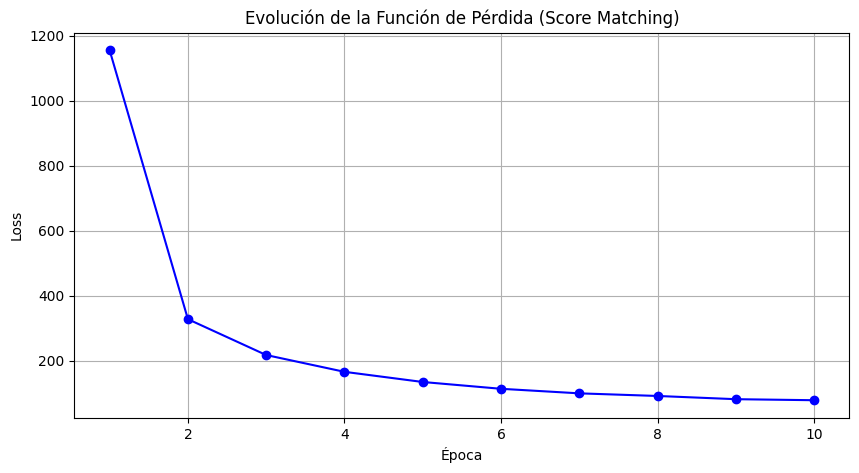

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', linestyle='-')
plt.title('Evolución de la Función de Pérdida (Score Matching)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.

In [29]:
import torch
from score_model_digits_color import ScoreNet as ScoreNetColor
from diffusion_lib import VEProcess, EulerMaruyamaSampler, GenerativeDiffusionModel

device = torch.device('cpu')

# ── Load pre-trained model ────────────────────────────────────────────────────
ve_process = VEProcess(sigma=25.0)
score_model = ScoreNetColor(marginal_prob_std=ve_process.sigma_t)

n_epochs = 500
checkpoint = torch.load(
    f'digit_6_{n_epochs}_epochs.pth',
    map_location=device,
    weights_only=True,
)
score_model.load_state_dict(checkpoint)

# ── Generative model + sampling with full trajectory ─────────────────────────
gm = GenerativeDiffusionModel(ve_process, EulerMaruyamaSampler(), score_model, device)

n_images = 5
synthetic_images_t = gm.sample(
    n_images=n_images,
    img_shape=(3, 32, 32),
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_t.shape}")

Dimensiones finales: torch.Size([5, 3, 32, 32, 501])


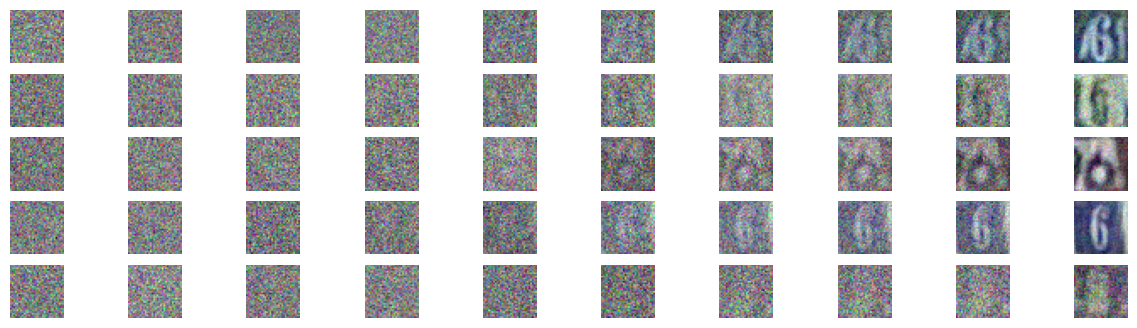

In [30]:
from diffusion_utilities import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.
$$    
    dX_t = \left[
        -\frac{\beta(t)}{2}\,X_t
        - \beta(t)\,\nabla_{x}\log p_t(X_t)
    \right]dt
    + \sqrt{\beta(t)}\,d\bar{W}_t
$$

1. Explain how the probability flow ODE can be used to generate samples from  $p_0\left(\mathbf{x} \right)$.
2. Implement and illustrate the use of this method to generate synthetic images of handwritten digits. 
3. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.

In [31]:
import torch
from score_model_digits_color import ScoreNet as ScoreNetColor
from diffusion_lib import VEProcess, ProbabilityFlowODESampler, GenerativeDiffusionModel

device = torch.device('cpu')

# ── Load pre-trained model ────────────────────────────────────────────────────
ve_process = VEProcess(sigma=25.0)
score_model = ScoreNetColor(marginal_prob_std=ve_process.sigma_t)

checkpoint = torch.load(
    'digit_6_500_epochs.pth',
    map_location=device,
    weights_only=True,
)
score_model.load_state_dict(checkpoint)
print("Modelo cargado.")

# ── Generative model + ODE sampling with full trajectory ─────────────────────
gm_ode = GenerativeDiffusionModel(ve_process, ProbabilityFlowODESampler(), score_model, device)

n_images = 5
trajectory = gm_ode.sample(
    n_images=n_images,
    img_shape=(3, 32, 32),
    n_steps=500,
    return_trajectory=True,
)

print(f"Trayectoria ODE: {trajectory.shape}")

Modelo cargado.
Trayectoria ODE: torch.Size([5, 3, 32, 32, 501])


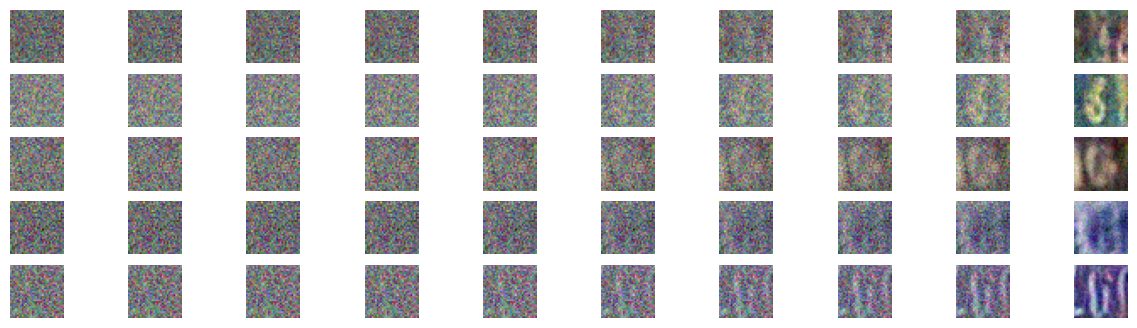

In [32]:
from diffusion_utilities import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    images=trajectory,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

## Exercise 2:  Generative AI based on diffusion models: The Ornstein-Uhlenbeck process

In this exercise, the training data is generated by injecting noise using Brownian motion (variance preserving diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t) + \sqrt{\beta(t)} d\mathbf{W}(t) 
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?

We will unveil the distribution of $\mathbf{x}(t)$ using the solution to the Ornstein-Uhlbeck SDE:
$$
\mathbf{x}(t) = e^{-\frac{1}{2}\int_0^t \beta(s)\,ds}\,\mathbf{x}_0 + \int_0^t e^{-\frac{1}{2}\int_\tau^t \beta(s)\,ds} \sqrt{\beta(\tau)}\, d\mathbf{W}(\tau)
$$
$$
\mu(t) = e^{-\frac{1}{2}\int_0^t \beta(s)\,ds}\,\mathbf{x}_0     \xrightarrow{t \to \infty} \mathbf{0}
$$
$$
\sigma^2(t) = e^{-\int_0^t \beta(s)\,ds} \int_0^t e^{\int_0^\tau \beta(s)\,ds}\,\beta(\tau)\,d\tau     \xrightarrow{t \to \infty} 1 
$$
Therefore, as $t \to \infty$:
 
$$
\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{0},\ \mathbf{I}\right)
$$
2. What is the SDE for the time-reversed process? 
 
$$
d\mathbf{x} = \left[-\frac{1}{2}\beta(t)\mathbf{x} - \beta(t)\,\nabla_{\mathbf{x}}\log p_t(\mathbf{x})\right]dt + \sqrt{\beta(t)}\,d\bar{\mathbf{W}}
$$
3. For the synthesis of new images
   1. In what interval is the reverse process SDE integrated?
        We need to integrate from the furthest moment of the forward process, in this case $t=T$ until the original moment $t=0$
        $$
        t \in [T, 0]
        $$
   2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled? 
        
        Knowing that $\tilde{\mathbf{x}}(T) \sim \mathcal{N}\!\left(\mathbf{0},\, \sigma^2(T)\,\mathbf{I}\right)$ it's easy to see that $\pi\left(\mathbf{x} \right) \sim \mathcal{N}\!\left(\mathbf{0},\ \mathbf{I}\right)$

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules
1. Using the linear noise schedule.


In [54]:
from diffusion_lib import VPProcess, LinearSchedule

vp_process = VPProcess(schedule=LinearSchedule())
score_model_vp_lin = ScoreNet(marginal_prob_std=vp_process.sigma_t).to(device)
gm_vp_lin = GenerativeDiffusionModel(vp_process, EulerMaruyamaSampler(), score_model_vp_lin, device)
optimizer = optim.Adam(score_model_vp_lin.parameters(), lr=1e-3)

In [67]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 500
loss_history = []

score_model_vp_lin.train()

print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        loss = gm_vp_lin.compute_loss(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

torch.save(score_model_vp_lin.state_dict(), 'mnist_vp_linear_trained.pth')

Entrenando en cuda...
Epoch 1/500 | Loss: 30.9178
Epoch 2/500 | Loss: 30.5775
Epoch 3/500 | Loss: 27.6889
Epoch 4/500 | Loss: 29.8256
Epoch 5/500 | Loss: 27.1520
Epoch 6/500 | Loss: 27.7444
Epoch 7/500 | Loss: 28.7330
Epoch 8/500 | Loss: 26.9908
Epoch 9/500 | Loss: 27.0831
Epoch 10/500 | Loss: 25.5635
Epoch 11/500 | Loss: 27.3455
Epoch 12/500 | Loss: 27.1386
Epoch 13/500 | Loss: 27.7989
Epoch 14/500 | Loss: 26.3327
Epoch 15/500 | Loss: 27.5321
Epoch 16/500 | Loss: 27.1393
Epoch 17/500 | Loss: 26.9263
Epoch 18/500 | Loss: 26.4412
Epoch 19/500 | Loss: 24.7683
Epoch 20/500 | Loss: 27.6713
Epoch 21/500 | Loss: 29.1055
Epoch 22/500 | Loss: 27.6725
Epoch 23/500 | Loss: 28.9323
Epoch 24/500 | Loss: 26.8561
Epoch 25/500 | Loss: 27.6303
Epoch 26/500 | Loss: 26.3711
Epoch 27/500 | Loss: 26.1621
Epoch 28/500 | Loss: 30.0136
Epoch 29/500 | Loss: 30.1154
Epoch 30/500 | Loss: 26.6394
Epoch 31/500 | Loss: 25.1408
Epoch 32/500 | Loss: 27.7189
Epoch 33/500 | Loss: 26.3321
Epoch 34/500 | Loss: 26.8708
E

In [68]:
checkpoint = torch.load(
    'mnist_vp_linear_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_lin.load_state_dict(checkpoint)

n_images = 5
synthetic_images_vp_lin = gm_vp_lin.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   # ScoreNet (score_model.py) has no padding → 28x28 only
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_lin.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


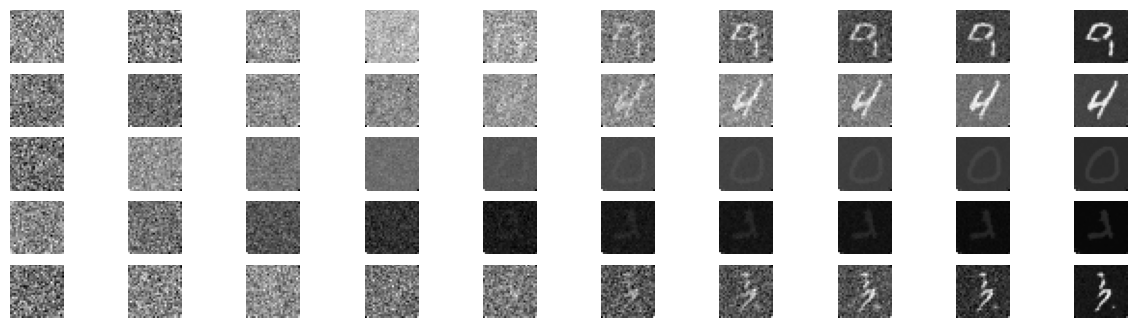

In [70]:
from diffusion_utilities import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_lin.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

2. Using the cosine noise schedule.


In [91]:
from diffusion_lib import CosineSchedule
vp_process_cos= VPProcess(schedule=CosineSchedule())
score_model_vp_cos = ScoreNet(marginal_prob_std=vp_process_cos.sigma_t).to(device)
gm_vp_cos = GenerativeDiffusionModel(vp_process_cos, EulerMaruyamaSampler(), score_model_vp_cos, device)
optimizer = optim.Adam(score_model_vp_cos.parameters(), lr=1e-3)

In [92]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 500
loss_history = []

score_model_vp_cos.train()

print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        loss = gm_vp_cos.compute_loss(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

torch.save(score_model_vp_cos.state_dict(), 'mnist_vp_cosine_trained.pth')

Entrenando en cuda...
Epoch 1/500 | Loss: 1387.3529
Epoch 2/500 | Loss: 415.4628
Epoch 3/500 | Loss: 286.5251
Epoch 4/500 | Loss: 219.2134
Epoch 5/500 | Loss: 187.6468
Epoch 6/500 | Loss: 155.5657
Epoch 7/500 | Loss: 146.8515
Epoch 8/500 | Loss: 135.9094
Epoch 9/500 | Loss: 124.0949
Epoch 10/500 | Loss: 115.7833
Epoch 11/500 | Loss: 111.0345
Epoch 12/500 | Loss: 102.4471
Epoch 13/500 | Loss: 100.8366
Epoch 14/500 | Loss: 92.7986
Epoch 15/500 | Loss: 90.3478
Epoch 16/500 | Loss: 90.0882
Epoch 17/500 | Loss: 90.5099
Epoch 18/500 | Loss: 87.1361
Epoch 19/500 | Loss: 78.4484
Epoch 20/500 | Loss: 77.2648
Epoch 21/500 | Loss: 75.1417
Epoch 22/500 | Loss: 75.6471
Epoch 23/500 | Loss: 75.9685
Epoch 24/500 | Loss: 72.1578
Epoch 25/500 | Loss: 69.6143
Epoch 26/500 | Loss: 71.0328
Epoch 27/500 | Loss: 68.6370
Epoch 28/500 | Loss: 69.2069
Epoch 29/500 | Loss: 69.9232
Epoch 30/500 | Loss: 67.4598
Epoch 31/500 | Loss: 66.7613
Epoch 32/500 | Loss: 62.6452
Epoch 33/500 | Loss: 60.7239
Epoch 34/500 | L

In [89]:
checkpoint = torch.load(
    'mnist_vp_cosine_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_cos.load_state_dict(checkpoint)

n_images = 5
synthetic_images_vp_cos = gm_vp_cos.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_cos.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


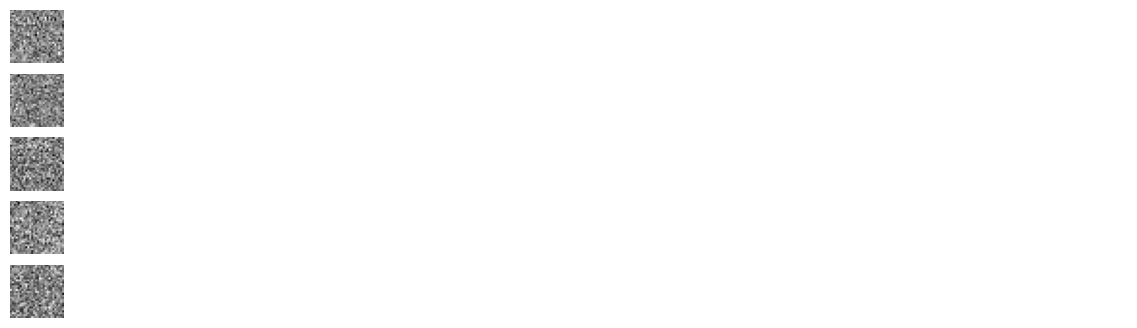

In [90]:
from diffusion_utilities import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_cos.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

3. Using a third noise schedule of your choice.

## Exercise 3:  Evaluation of the quality of the generated images
1. Describe, and compare the characteristics, advantages, and disadvantages of the following measures of quality for generative IA models for images:
    1. The negative log-likelihood (NLL).
    2. Bits per dimension (BPD). 
    3. Fréchet Inception Distance (FID).
    4. A third measure of your choice.
2. Compare using BPD the different diffusion models (Brownian motion, Ornstein-Uhlenbeck), noising schedules (linear, cosine, etc.), and sampling strategies (SDE, ODE) implemented.